In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, 
    f1_score, matthews_corrcoef, brier_score_loss, 
    confusion_matrix, PrecisionRecallDisplay, RocCurveDisplay,
    classification_report
)
from sklearn.calibration import calibration_curve, CalibrationDisplay
import warnings

In [3]:
warnings.filterwarnings('ignore')

print("--- 1. Loading the best Model & Holdout Data ---")
# Load the raw dataset
df = pd.read_parquet('../data/processed/train_data_ml_ready.parquet')
X = df.drop(columns=['target', 'customer_ID'])
y = df['target']

# Create a fast 20% holdout set to generate unbiased metrics
# We use random_state=42 to ensure we get the exact same split as before
_, X_test, _, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Load your finalized model
model_path = '../model_save/xgboost_optimized_final.joblib'
final_model = joblib.load(model_path)
print(" Model and Data successfully loaded.")

--- 1. Loading the best Model & Holdout Data ---
 Model and Data successfully loaded.


In [5]:
print("\n--- 2. Generating Predictions ---")
# Predict probabilities (the raw % chance of default)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Convert probabilities to hard predictions using a standard 0.50 threshold
# (Anyone > 50% risk is flagged as a Default)
threshold = 0.50
y_pred = (y_prob >= threshold).astype(int)


--- 2. Generating Predictions ---


In [6]:
print("\n--- 3. Calculating the Hard Metrics ---")
auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
brier = brier_score_loss(y_test, y_prob)

print(f" ROC AUC:       {auc:.4f} (Overall ranking power)")
print(f" Precision:     {precision:.4f} (When we predict Default, how often are we right?)")
print(f" Recall:        {recall:.4f} (Out of all actual Defaults, how many did we catch?)")
print(f" F1 Score:      {f1:.4f} (The harmonic mean of Precision and Recall)")
print(f" MCC:           {mcc:.4f} (Overall quality on imbalanced data. 1.0 is perfect)")
print(f" Brier Score:   {brier:.4f} (Probability accuracy. Closer to 0.0 is better)")


--- 3. Calculating the Hard Metrics ---
 ROC AUC:       0.9790 (Overall ranking power)
 Precision:     0.7634 (When we predict Default, how often are we right?)
 Recall:        0.9547 (Out of all actual Defaults, how many did we catch?)
 F1 Score:      0.8484 (The harmonic mean of Precision and Recall)
 MCC:           0.7970 (Overall quality on imbalanced data. 1.0 is perfect)
 Brier Score:   0.0616 (Probability accuracy. Closer to 0.0 is better)


In [9]:
print("\n--- 3.5. Full Classification Report ---")
# target_names makes the output infinitely easier to read for business users
print(classification_report(y_test, y_pred, target_names=['Paid (0)', 'Default (1)']))


--- 3.5. Full Classification Report ---
              precision    recall  f1-score   support

    Paid (0)       0.98      0.90      0.94     68017
 Default (1)       0.76      0.95      0.85     23766

    accuracy                           0.91     91783
   macro avg       0.87      0.93      0.89     91783
weighted avg       0.93      0.91      0.91     91783




--- 4. Visualizing the Results ---


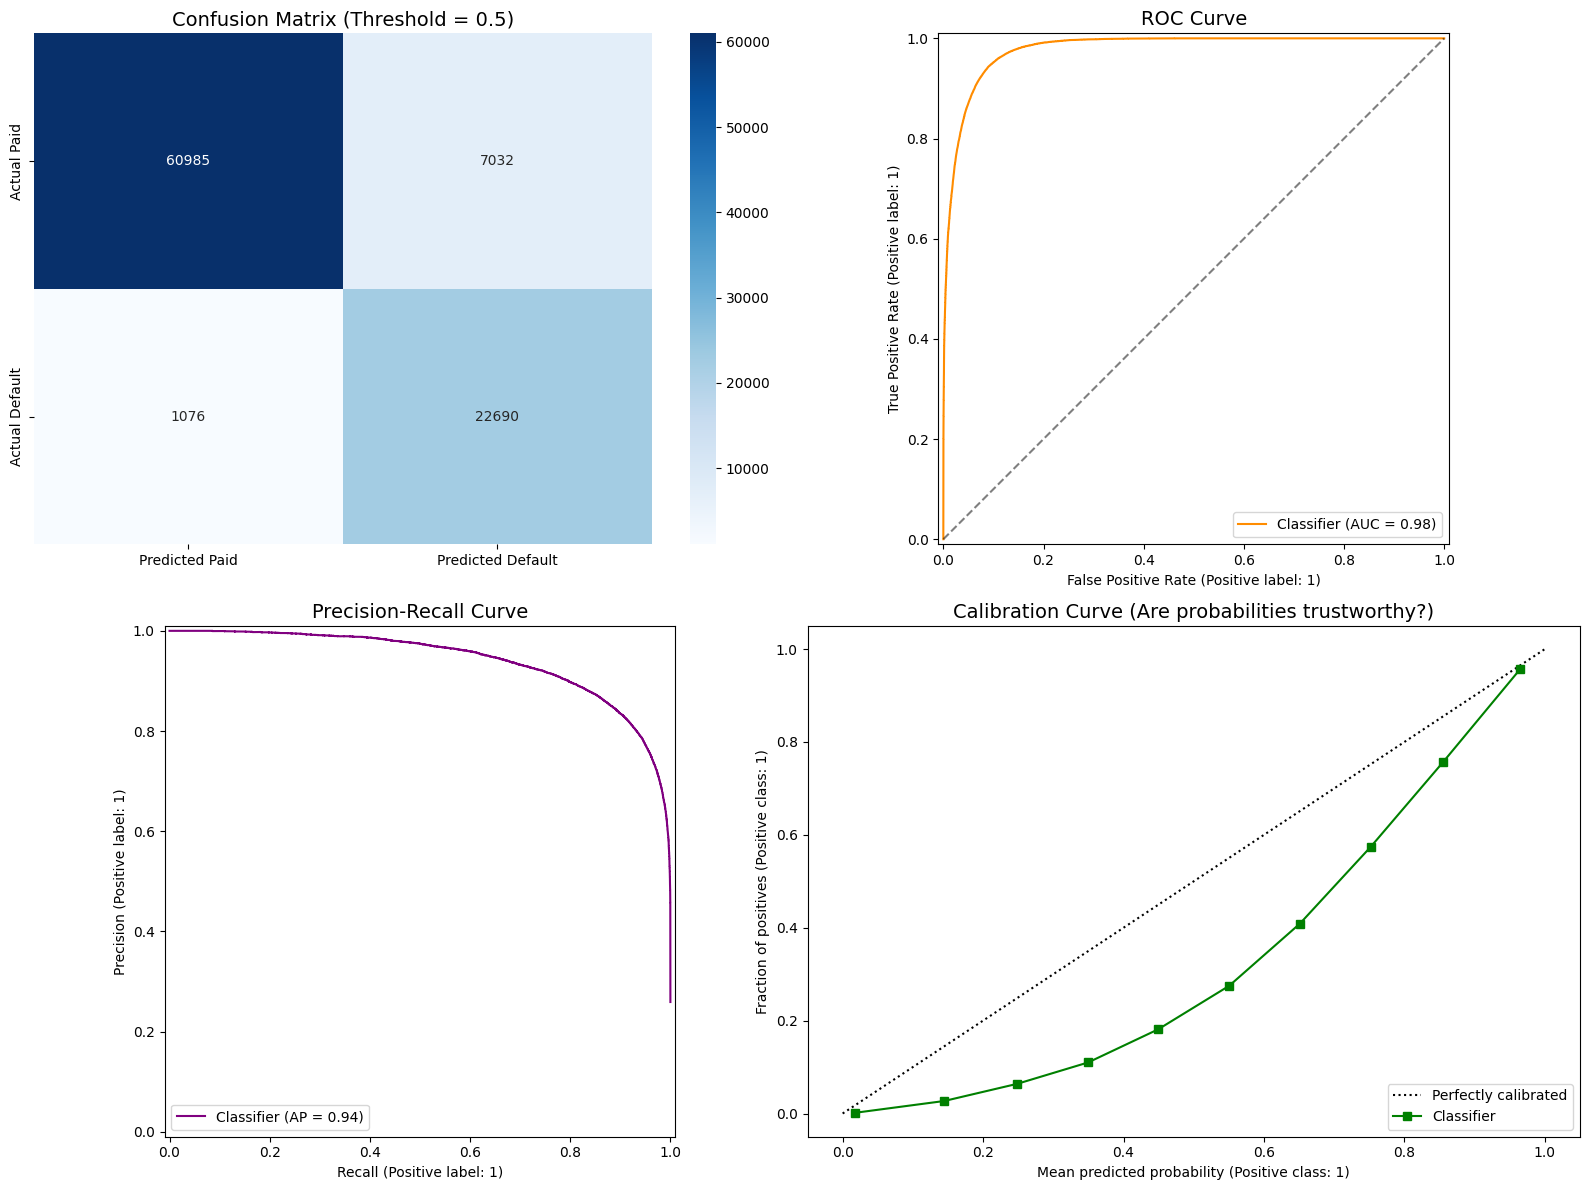

In [7]:
print("\n--- 4. Visualizing the Results ---")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: The Confusion Matrix (The Business Reality)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
            xticklabels=['Predicted Paid', 'Predicted Default'], 
            yticklabels=['Actual Paid', 'Actual Default'])
axes[0, 0].set_title(f'Confusion Matrix (Threshold = {threshold})', fontsize=14)

# Plot 2: ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0, 1], color='darkorange')
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0, 1].set_title('ROC Curve', fontsize=14)

# Plot 3: Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Precision-Recall Curve', fontsize=14)

# Plot 4: Calibration Curve (Reliability Diagram)
CalibrationDisplay.from_predictions(y_test, y_prob, n_bins=10, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Calibration Curve (Are probabilities trustworthy?)', fontsize=14)

plt.tight_layout()
plt.show()

1. The Classification Report (The Business Reality)
The text output you printed perfectly explains the model's behavior at the 0.50 threshold.

The "Default" Row (Catching the Bad Apples): Recall is 0.95. That means out of all the people who actually defaulted, your model caught 95% of them. That is an incredibly safe model. The Precision is 0.76, meaning when your model denies someone, it is right 76% of the time (the other 24% are false alarms).

The "Paid" Row (Approving the Good Apples):  Precision here is 0.98. This is a massive statistic. It means that when your model approves a customer, you can be 98% mathematically certain that they will actually pay their bill.

2. The Confusion Matrix (The Raw Dollars)
This translates the percentages above into actual human beings.

The Massive Success: Look at the bottom right. 22,690 defaults were successfully caught and prevented.

The Minor Leakage: Look at the bottom left. Only 1,076 defaults slipped through the cracks.

The False Alarms: Look at the top right. 7,032 perfectly good customers were falsely flagged as defaults. In banking, we are usually okay with this! It is much cheaper to accidentally deny 7,000 good customers than to accidentally approve 7,000 defaulters.

3. ROC and PR Curves (The Bragging Rights)
These are the charts you show to other Data Scientists.

ROC Curve (0.98 AUC): The orange line is shoved almost perfectly into the top-left corner. This proves model is elite at ranking risk.

Precision-Recall Curve (0.94 AP): Because dataset is imbalanced (most people pay), this is the harder chart to master. The fact that the purple line stays completely flat at the top before finally dropping at the very end proves model doesn't just guess "Paid" for everyone.

4. The Calibration Curve (The Fascinating Quirk)
Look closely at the bottom-right green chart. The dotted line is "Perfect Calibration." Your green line sags below it.

What this means: Your model is slightly pessimistic (paranoid).
Look at the 0.8 mark on the bottom X-axis (Model predicts 80% risk). If you trace that straight up to the green line, the Y-axis sits at about 0.6 (Only 60% actually defaulted).

Your model systematically thinks people are slightly riskier than they actually are.

Banks actually love this because it is structurally conservative. If you wanted to fix it to be perfectly accurate, you would use a technique called "Platt Scaling" or "Isotonic Regression," but for this Kaggle competition, the ranking power (AUC) matters far more than the exact probability percentage.